In [10]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.compose import TransformedTargetRegressor
from IPython.display import display
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.dpi": 110,
    }
)

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", __import__("sklearn").__version__)

# Stream logs immediately (notebooks otherwise look frozen until a cell finishes)
try:
    sys.stdout.reconfigure(line_buffering=True)
    sys.stderr.reconfigure(line_buffering=True)
except Exception:
    pass


def progress(step, detail=""):
    """Timestamped line that shows up while Run All is still going."""
    ts = time.strftime("%H:%M:%S")
    line = f"[{ts}] {step}" + (f"  |  {detail}" if detail else "")
    print(line, flush=True)
    print(line, file=sys.stderr, flush=True)

progress("Cluster A", "libraries loaded")


numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
[21:20:44] Cluster A  |  libraries loaded


[21:20:44] Cluster A  |  libraries loaded


In [11]:
# ---------------------------------------------------------------------------
# Runtime switches
# FAST_DEV=True  -> 120k-row working sample after cleaning (fast iteration)
# FAST_DEV=False -> full cleaned data for linear / tree / boosting models
# ---------------------------------------------------------------------------
FAST_DEV = False
WORKING_SAMPLE_SIZE = 120_000  # used only when FAST_DEV is True

PLOT_SAMPLE = 25_000
TEST_SIZE = 0.20
EVAL_TEST_SIZE = 50_000  # shared test sample scored by every model

# Domain cleaning bounds
NYC_LONG_MIN, NYC_LONG_MAX = -74.30, -73.70
NYC_LAT_MIN, NYC_LAT_MAX = 40.50, 40.90
MIN_DURATION_S, MAX_DURATION_S = 60, 7200  # 1 minute to 2 hours
MIN_PASSENGERS, MAX_PASSENGERS = 1, 6

# Subsets for algorithms whose training cost is super-linear in n
SVR_TRAIN_SIZE = 12_000
KNN_TRAIN_SIZE = 40_000
TUNE_SAMPLE_SIZE = 40_000  # used inside Grid/Randomized search for forest

DATA_PATH = Path("../data/nyc_taxi_trip_duration.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/nyc_taxi_trip_duration.csv")

RESULTS_DIR = Path("../results") if Path("../data").exists() else Path("results")
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVED_FIGURES = []

print(f"FAST_DEV = {FAST_DEV}")
print(f"Data path: {DATA_PATH.resolve()}")
print(f"Results folder: {RESULTS_DIR.resolve()}")
progress("Cluster A", f"FAST_DEV={FAST_DEV}  data={DATA_PATH.name}")


FAST_DEV = False
Data path: D:\ML_CAPSTONE\data\nyc_taxi_trip_duration.csv
Results folder: D:\ML_CAPSTONE\results
[21:20:44] Cluster A  |  FAST_DEV=False  data=nyc_taxi_trip_duration.csv


[21:20:44] Cluster A  |  FAST_DEV=False  data=nyc_taxi_trip_duration.csv


In [12]:
file_path = "nyc_taxi_trip_duration.csv"  # or "nyc_taxi_trip_duration.csv" if it's in the same folder

progress("Cluster B", f"loading {file_path}")
df_raw = pd.read_csv(file_path)
print(f"Loaded {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

[21:20:44] Cluster B  |  loading nyc_taxi_trip_duration.csv


[21:20:44] Cluster B  |  loading nyc_taxi_trip_duration.csv


Loaded 352,000 rows x 11 columns


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2979302,2,2016-04-15 07:19:25,2016-04-15 07:23:00,2,-73.9933,40.7525,-74.0008,40.7576,N,215
1,id1901673,1,2016-05-28 23:25:47,2016-05-28 23:57:57,4,-73.7836,40.6487,-73.9728,40.7556,N,1930
2,id2241407,2,2016-02-22 09:43:15,2016-02-22 10:02:32,2,-73.9491,40.7733,-73.9684,40.7623,N,1157
3,id1614454,2,2016-05-18 10:45:48,2016-05-18 10:50:04,5,-73.9894,40.7402,-73.9848,40.7422,N,256
4,id0439485,2,2016-05-05 21:27:15,2016-05-05 21:32:05,1,-73.9907,40.7509,-73.9895,40.7567,N,290


In [13]:
audit = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "non_null": df_raw.notna().sum(),
        "missing": df_raw.isna().sum(),
        "missing_pct": 100 * df_raw.isna().mean(),
        "n_unique": df_raw.nunique(),
    }
)
audit


,dtype,non_null,missing,missing_pct,n_unique
id,str,352000,0,0.0000,352000
vendor_id,int64,352000,0,0.0000,2
pickup_datetime,str,352000,0,0.0000,347174
dropoff_datetime,str,352000,0,0.0000,347284
passenger_count,int64,352000,0,0.0000,7
pickup_longitude,float64,352000,0,0.0000,16616
pickup_latitude,float64,352000,0,0.0000,34555
dropoff_longitude,float64,352000,0,0.0000,22427
dropoff_latitude,float64,352000,0,0.0000,44349
store_and_fwd_flag,str,352000,0,0.0000,2


In [14]:
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Duplicate ids:", int(df_raw["id"].duplicated().sum()))
print()
print("vendor_id")
print(df_raw["vendor_id"].value_counts().sort_index().to_string())
print()
print("store_and_fwd_flag")
print(df_raw["store_and_fwd_flag"].value_counts().to_string())
print()
print("passenger_count")
print(df_raw["passenger_count"].value_counts().sort_index().to_string())
print()
print("trip_duration (seconds)")
display(df_raw["trip_duration"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame())
print(
    f"pickup_datetime range: {df_raw['pickup_datetime'].min()}  →  {df_raw['pickup_datetime'].max()}"
)


Duplicate rows: 0
Duplicate ids: 0

vendor_id
vendor_id
1    164074
2    187926

store_and_fwd_flag
store_and_fwd_flag
N    350085
Y      1915

passenger_count
passenger_count
0        12
1    249398
2     50572
3     14424
4      6956
5     19008
6     11630

trip_duration (seconds)


,trip_duration
count,"352,000.0000"
mean,947.9198
std,"3,117.5860"
min,1.0000
1%,89.0000
5%,181.0000
25%,397.0000
50%,661.0000
75%,"1,074.0000"
95%,"2,104.0000"


pickup_datetime range: 2016-01-01 00:01:20  →  2016-06-30 23:57:49


In [15]:
progress("Cluster C", "EDA helpers + plot sample")
def take_plot_sample(frame: pd.DataFrame, n: int = PLOT_SAMPLE) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n, random_state=RANDOM_STATE)


def finalise(fig=None, name=None):
    plt.tight_layout()
    fig = fig or plt.gcf()
    if name is None:
        titles = [ax.get_title() for ax in fig.axes if ax.get_title()]
        name = titles[0] if titles else "figure"
    slug = "".join(ch if ch.isalnum() else "_" for ch in name.lower())
    slug = "_".join(part for part in slug.split("_") if part)[:70]
    path = FIG_DIR / f"{len(SAVED_FIGURES) + 1:02d}_{slug}.png"
    fig.savefig(path, bbox_inches="tight", dpi=140)
    SAVED_FIGURES.append(path)
    plt.show()


eda = df_raw.copy()
eda["pickup_datetime"] = pd.to_datetime(eda["pickup_datetime"])
eda["pickup_hour"] = eda["pickup_datetime"].dt.hour
eda["pickup_dayofweek"] = eda["pickup_datetime"].dt.dayofweek
eda["log1p_duration"] = np.log1p(eda["trip_duration"])
plot_df = take_plot_sample(eda)
print(f"EDA plot sample: {len(plot_df):,} rows")


[21:20:49] Cluster C  |  EDA helpers + plot sample


[21:20:49] Cluster C  |  EDA helpers + plot sample


EDA plot sample: 25,000 rows


[21:20:50] Cluster C  |  plot: target distribution


[21:20:50] Cluster C  |  plot: target distribution


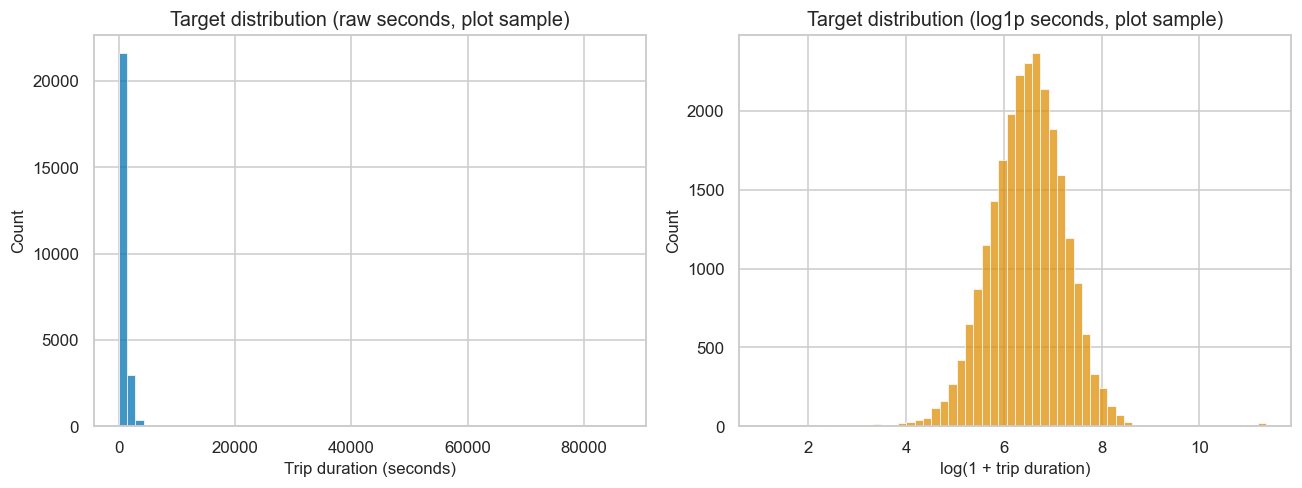

Skewness of trip_duration (full data): 25.64  |  skewness of log1p: -0.28
Median = 661s  |  mean = 948s  |  99th percentile = 3420s


In [16]:
progress("Cluster C", "plot: target distribution")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.histplot(plot_df["trip_duration"], bins=60, ax=axes[0], color=sns.color_palette("colorblind")[0])
axes[0].set_title("Target distribution (raw seconds, plot sample)")
axes[0].set_xlabel("Trip duration (seconds)")
axes[0].set_ylabel("Count")

sns.histplot(plot_df["log1p_duration"], bins=60, ax=axes[1], color=sns.color_palette("colorblind")[1])
axes[1].set_title("Target distribution (log1p seconds, plot sample)")
axes[1].set_xlabel("log(1 + trip duration)")
axes[1].set_ylabel("Count")

finalise(fig)
print(
    f"Skewness of trip_duration (full data): {eda['trip_duration'].skew():.2f}  |  "
    f"skewness of log1p: {eda['log1p_duration'].skew():.2f}"
)
print(
    f"Median = {eda['trip_duration'].median():.0f}s  |  "
    f"mean = {eda['trip_duration'].mean():.0f}s  |  "
    f"99th percentile = {eda['trip_duration'].quantile(0.99):.0f}s"
)


[21:20:53] Cluster C  |  plot: passenger / vendor / hour


[21:20:53] Cluster C  |  plot: passenger / vendor / hour


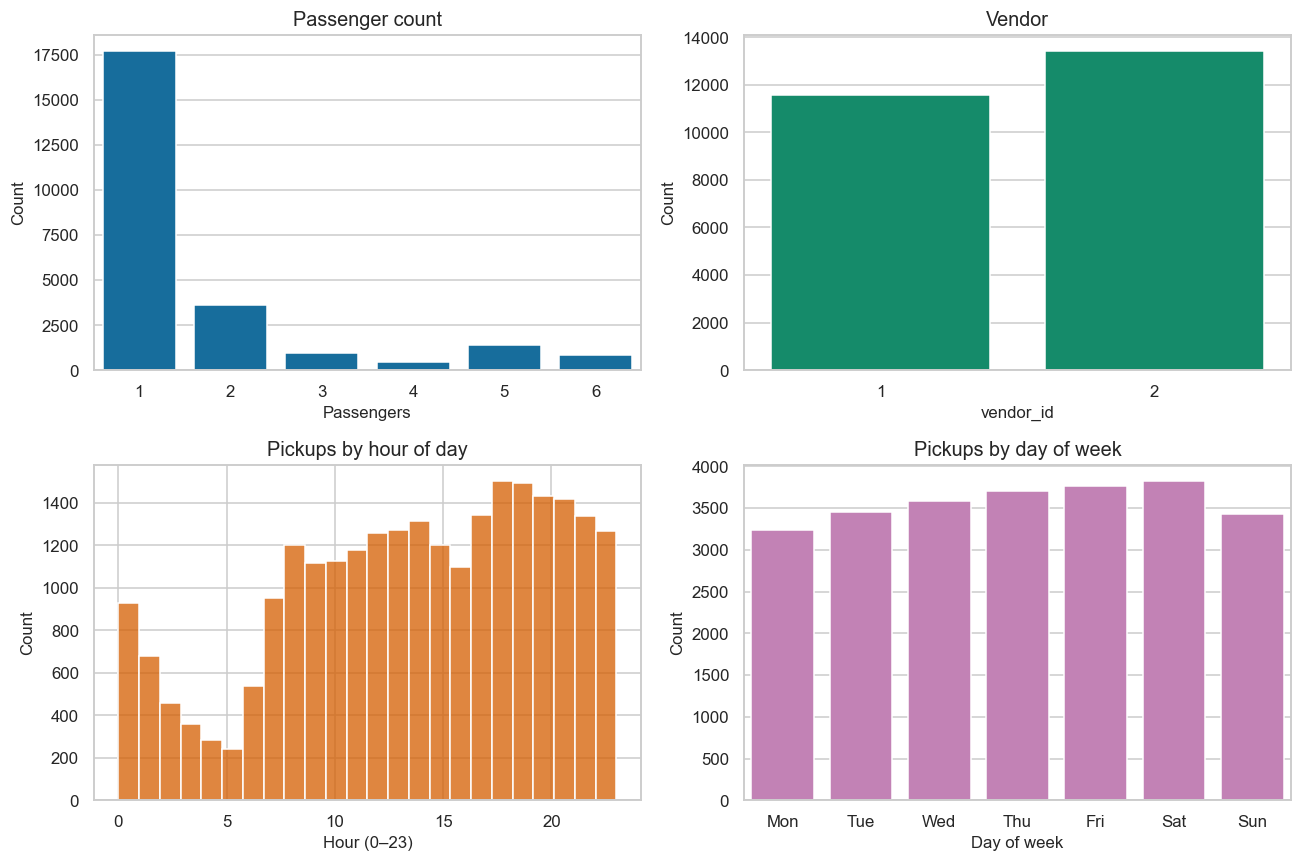

In [17]:
progress("Cluster C", "plot: passenger / vendor / hour")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=plot_df, x="passenger_count", ax=axes[0, 0], color=sns.color_palette("colorblind")[0])
axes[0, 0].set_title("Passenger count")
axes[0, 0].set_xlabel("Passengers")
axes[0, 0].set_ylabel("Count")

sns.countplot(data=plot_df, x="vendor_id", ax=axes[0, 1], color=sns.color_palette("colorblind")[2])
axes[0, 1].set_title("Vendor")
axes[0, 1].set_xlabel("vendor_id")
axes[0, 1].set_ylabel("Count")

sns.histplot(plot_df["pickup_hour"], bins=24, ax=axes[1, 0], color=sns.color_palette("colorblind")[3])
axes[1, 0].set_title("Pickups by hour of day")
axes[1, 0].set_xlabel("Hour (0–23)")
axes[1, 0].set_ylabel("Count")

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.countplot(data=plot_df, x="pickup_dayofweek", ax=axes[1, 1], color=sns.color_palette("colorblind")[4])
axes[1, 1].set_title("Pickups by day of week")
axes[1, 1].set_xlabel("Day of week")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xticks(range(7), dow_labels)

finalise(fig)


[21:20:56] Cluster C  |  plot: pickup / dropoff map


[21:20:56] Cluster C  |  plot: pickup / dropoff map


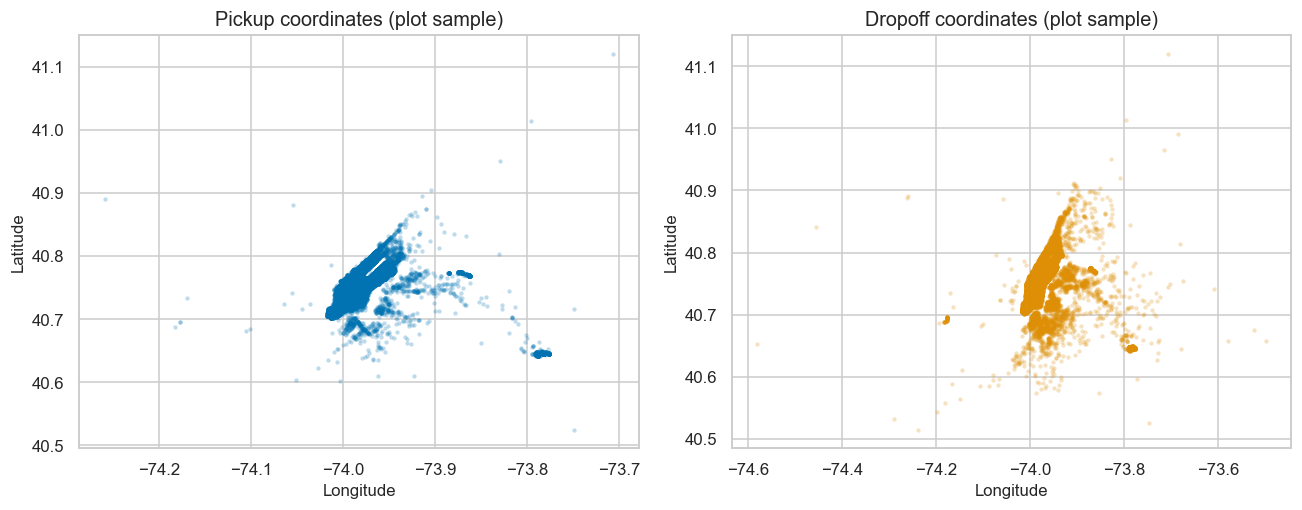

Pickup longitude range: -121.93334197998048 → -72.07433319091797
Pickup latitude range: 35.310306549072266 → 41.69679641723633


In [18]:
progress("Cluster C", "plot: pickup / dropoff map")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(
    data=plot_df,
    x="pickup_longitude",
    y="pickup_latitude",
    s=8,
    alpha=0.25,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("Pickup coordinates (plot sample)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sns.scatterplot(
    data=plot_df,
    x="dropoff_longitude",
    y="dropoff_latitude",
    s=8,
    alpha=0.25,
    ax=axes[1],
    linewidth=0,
    color=sns.color_palette("colorblind")[1],
)
axes[1].set_title("Dropoff coordinates (plot sample)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

finalise(fig)
print("Pickup longitude range:", eda["pickup_longitude"].min(), "→", eda["pickup_longitude"].max())
print("Pickup latitude range:", eda["pickup_latitude"].min(), "→", eda["pickup_latitude"].max())


[21:20:58] Cluster C  |  plot: distance vs duration


[21:20:58] Cluster C  |  plot: distance vs duration


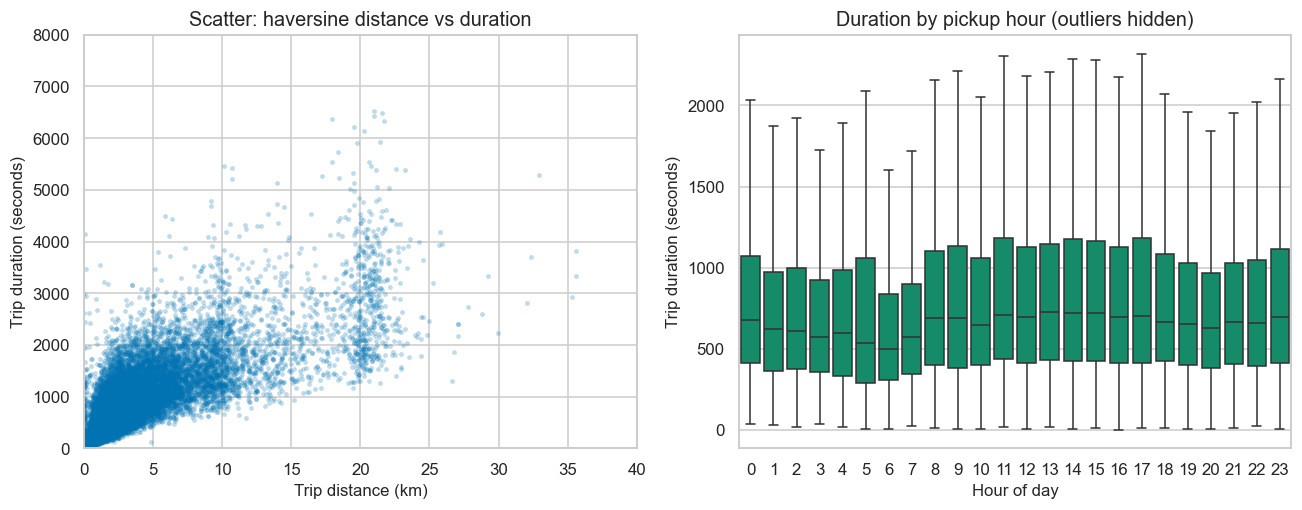

Pearson correlation (distance, duration) on full data: 0.160


In [19]:
progress("Cluster C", "plot: distance vs duration")
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = (np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


eda["trip_distance_km"] = haversine_km(
    eda["pickup_latitude"].to_numpy(),
    eda["pickup_longitude"].to_numpy(),
    eda["dropoff_latitude"].to_numpy(),
    eda["dropoff_longitude"].to_numpy(),
)
plot_df = take_plot_sample(eda)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(
    data=plot_df,
    x="trip_distance_km",
    y="trip_duration",
    s=10,
    alpha=0.25,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("Scatter: haversine distance vs duration")
axes[0].set_xlabel("Trip distance (km)")
axes[0].set_ylabel("Trip duration (seconds)")
axes[0].set_xlim(0, 40)
axes[0].set_ylim(0, 8000)

sns.boxplot(
    data=plot_df,
    x="pickup_hour",
    y="trip_duration",
    showfliers=False,
    ax=axes[1],
    color=sns.color_palette("colorblind")[2],
)
axes[1].set_title("Duration by pickup hour (outliers hidden)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Trip duration (seconds)")

finalise(fig)

corr_distance = eda[["trip_distance_km", "trip_duration"]].corr().iloc[0, 1]
print(f"Pearson correlation (distance, duration) on full data: {corr_distance:.3f}")


[21:21:01] Cluster C  |  plot: raw correlation heatmap


[21:21:01] Cluster C  |  plot: raw correlation heatmap


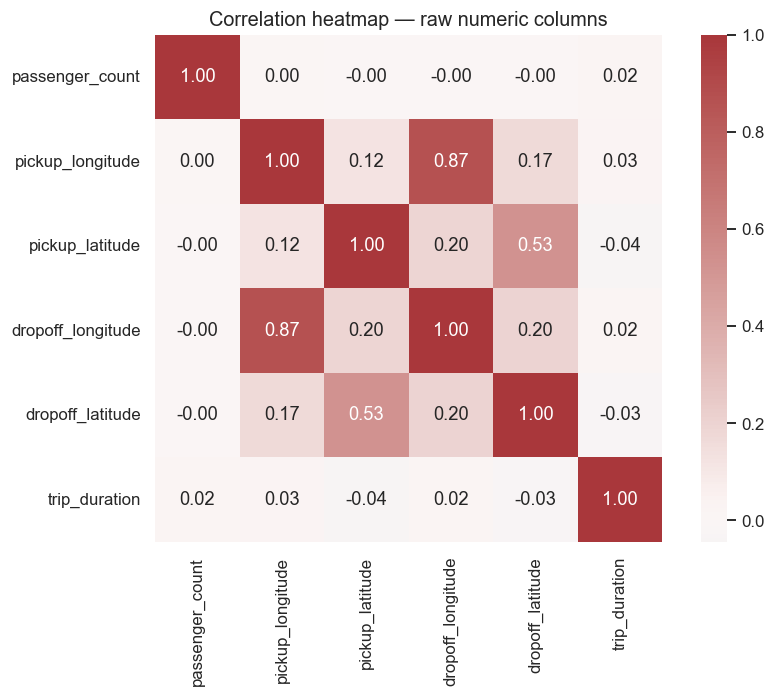

In [20]:
progress("Cluster C", "plot: raw correlation heatmap")
raw_numeric = [
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration",
]
corr_raw = eda[raw_numeric].corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    corr_raw,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax,
    square=True,
)
ax.set_title("Correlation heatmap — raw numeric columns")
finalise(fig)


In [21]:
progress("Cluster D", "cleaning impossible trips")
def apply_cleaning(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    tracker = []

    def log(step, before, after, note):
        tracker.append(
            {
                "step": step,
                "rows_before": before,
                "rows_after": after,
                "rows_removed": before - after,
                "pct_removed": 100 * (before - after) / before if before else 0.0,
                "note": note,
            }
        )

    out = frame.copy()
    n0 = len(out)
    log("loaded", n0, n0, "raw file")

    before = len(out)
    out = out.drop_duplicates()
    log("drop duplicate rows", before, len(out), "exact row duplicates")

    before = len(out)
    out = out.drop(columns=["id", "dropoff_datetime"])
    log("drop leakage / id columns", before, len(out), "id + dropoff_datetime removed (column drop only)")

    before = len(out)
    in_box = (
        out["pickup_longitude"].between(NYC_LONG_MIN, NYC_LONG_MAX)
        & out["pickup_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX)
        & out["dropoff_longitude"].between(NYC_LONG_MIN, NYC_LONG_MAX)
        & out["dropoff_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX)
    )
    out = out.loc[in_box]
    log("NYC bounding box", before, len(out), "[-74.30,-73.70] × [40.50,40.90]")

    before = len(out)
    out = out.loc[out["passenger_count"].between(MIN_PASSENGERS, MAX_PASSENGERS)]
    log("passenger_count 1–6", before, len(out), "drop 0 and 7+")

    before = len(out)
    out = out.loc[out["trip_duration"].between(MIN_DURATION_S, MAX_DURATION_S)]
    log("duration 60–7200 s", before, len(out), "drop cancelled / multi-day trips")

    out = out.reset_index(drop=True)
    report = pd.DataFrame(tracker)
    return out, report


df, cleaning_report = apply_cleaning(df_raw)
display(cleaning_report)
print(f"Cleaned table: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Retained {100 * len(df) / len(df_raw):.2f}% of the original file")


[21:21:03] Cluster D  |  cleaning impossible trips


[21:21:03] Cluster D  |  cleaning impossible trips


,step,rows_before,rows_after,rows_removed,pct_removed,note
0,loaded,352000,352000,0,0.0000,raw file
1,drop duplicate rows,352000,352000,0,0.0000,exact row duplicates
2,drop leakage / id columns,352000,352000,0,0.0000,id + dropoff_datetime removed (column drop only)
3,NYC bounding box,352000,351601,399,0.1134,"[-74.30,-73.70] × [40.50,40.90]"
4,passenger_count 1–6,351601,351589,12,0.0034,drop 0 and 7+
5,duration 60–7200 s,351589,349080,2509,0.7136,drop cancelled / multi-day trips


Cleaned table: 349,080 rows × 9 columns
Retained 99.17% of the original file


In [22]:
progress("Cluster E", "engineering distance / time features")
def manhattan_km(lat1, lon1, lat2, lon2):
    lat_km = 111.32
    lon_km = 111.32 * np.cos(np.radians((lat1 + lat2) / 2.0))
    return lat_km * np.abs(lat2 - lat1) + lon_km * np.abs(lon2 - lon1)


def bearing_deg(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = (np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2))
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360.0) % 360.0


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["pickup_datetime"] = pd.to_datetime(out["pickup_datetime"])
    lat1 = out["pickup_latitude"].to_numpy()
    lon1 = out["pickup_longitude"].to_numpy()
    lat2 = out["dropoff_latitude"].to_numpy()
    lon2 = out["dropoff_longitude"].to_numpy()

    out["trip_distance_km"] = haversine_km(lat1, lon1, lat2, lon2)
    out["manhattan_distance_km"] = manhattan_km(lat1, lon1, lat2, lon2)
    out["bearing_deg"] = bearing_deg(lat1, lon1, lat2, lon2)
    out["pickup_hour"] = out["pickup_datetime"].dt.hour.astype(int)
    out["pickup_dayofweek"] = out["pickup_datetime"].dt.dayofweek.astype(int)
    out["pickup_month"] = out["pickup_datetime"].dt.month.astype(int)
    out["is_weekend"] = (out["pickup_dayofweek"] >= 5).astype(int)
    rush = out["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]) & (out["is_weekend"] == 0)
    out["is_rush_hour"] = rush.astype(int)
    out = out.drop(columns=["pickup_datetime"])
    return out


df_fe = engineer_features(df)

if FAST_DEV and len(df_fe) > WORKING_SAMPLE_SIZE:
    df_fe = df_fe.sample(WORKING_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"FAST_DEV on: working sample is {len(df_fe):,} rows")
else:
    print(f"Modelling table: {len(df_fe):,} rows (full cleaned data)")

print("Engineered columns added: trip_distance_km, manhattan_distance_km, bearing_deg,")
print("pickup_hour, pickup_dayofweek, pickup_month, is_weekend, is_rush_hour")
df_fe.head()


[21:21:04] Cluster E  |  engineering distance / time features


[21:21:04] Cluster E  |  engineering distance / time features


Modelling table: 349,080 rows (full cleaned data)
Engineered columns added: trip_distance_km, manhattan_distance_km, bearing_deg,
pickup_hour, pickup_dayofweek, pickup_month, is_weekend, is_rush_hour


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_distance_km,manhattan_distance_km,bearing_deg,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour
0,2,2,-73.9933,40.7525,-74.0008,40.7576,N,215,0.8538,1.2068,311.7018,7,4,4,0,1
1,1,4,-73.7836,40.6487,-73.9728,40.7556,N,1930,19.8926,27.8675,306.7405,23,5,5,1,0
2,2,2,-73.9491,40.7733,-73.9684,40.7623,N,1157,2.0265,2.8401,233.1592,9,0,2,0,1
3,2,5,-73.9894,40.7402,-73.9848,40.7422,N,256,0.4440,0.6044,60.9667,10,2,5,0,0
4,2,1,-73.9907,40.7509,-73.9895,40.7567,N,290,0.6572,0.7462,8.3211,21,3,5,0,0


[21:21:05] Cluster E  |  plot: engineered heatmap


[21:21:05] Cluster E  |  plot: engineered heatmap


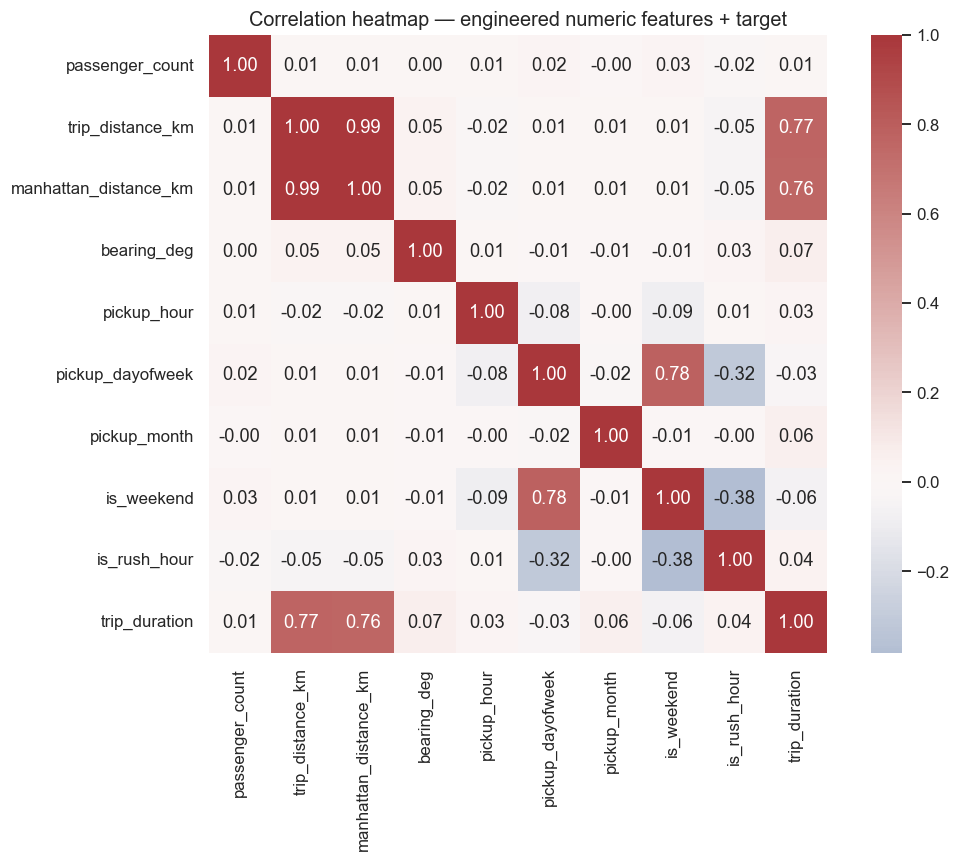

Correlation with trip_duration:
trip_distance_km         0.7714
manhattan_distance_km    0.7579
bearing_deg              0.0666
is_weekend              -0.0650
pickup_month             0.0569
is_rush_hour             0.0395
pickup_dayofweek        -0.0347
pickup_hour              0.0284
passenger_count          0.0146


In [23]:
progress("Cluster E", "plot: engineered heatmap")
engineered_cols = [
    "passenger_count",
    "trip_distance_km",
    "manhattan_distance_km",
    "bearing_deg",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "is_rush_hour",
    "trip_duration",
]
corr_fe = df_fe[engineered_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_fe,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=ax,
    square=True,
)
ax.set_title("Correlation heatmap — engineered numeric features + target")
finalise(fig)

print("Correlation with trip_duration:")
print(corr_fe["trip_duration"].drop("trip_duration").sort_values(key=np.abs, ascending=False).to_string())


[21:21:08] Cluster E  |  plot: cleaned distance vs duration


[21:21:08] Cluster E  |  plot: cleaned distance vs duration


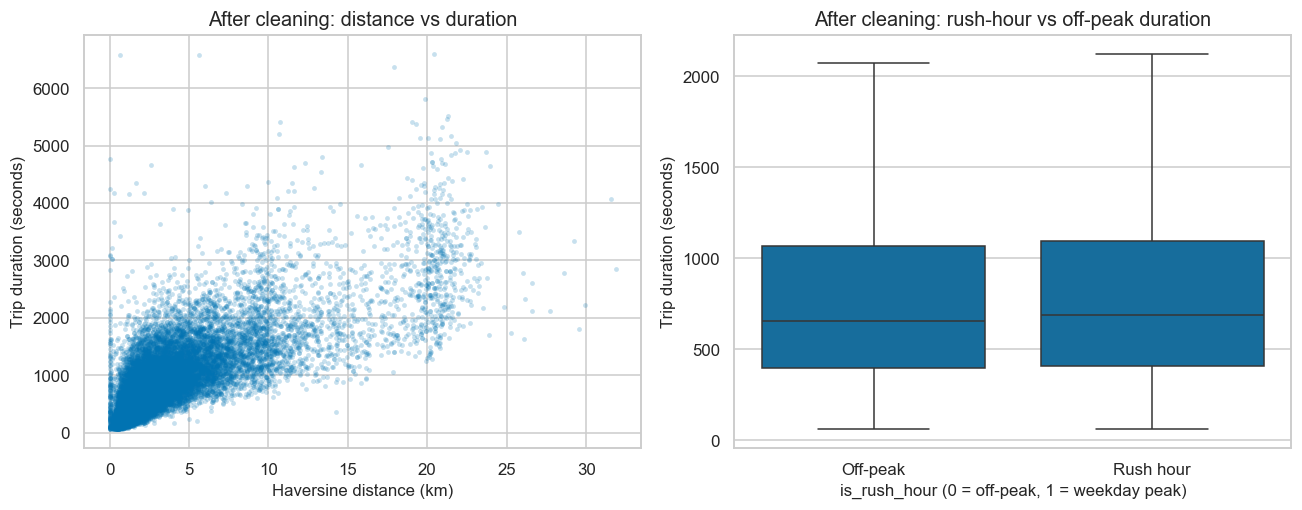

In [24]:
progress("Cluster E", "plot: cleaned distance vs duration")
plot_fe = take_plot_sample(df_fe)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.scatterplot(
    data=plot_fe,
    x="trip_distance_km",
    y="trip_duration",
    s=10,
    alpha=0.22,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("After cleaning: distance vs duration")
axes[0].set_xlabel("Haversine distance (km)")
axes[0].set_ylabel("Trip duration (seconds)")

sns.boxplot(
    data=plot_fe,
    x="is_rush_hour",
    y="trip_duration",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("After cleaning: rush-hour vs off-peak duration")
axes[1].set_xlabel("is_rush_hour (0 = off-peak, 1 = weekday peak)")
axes[1].set_ylabel("Trip duration (seconds)")
axes[1].set_xticks([0, 1], ["Off-peak", "Rush hour"])

finalise(fig)


In [25]:
progress("Cluster F", "80/20 stratified split")
TARGET = "trip_duration"
y = df_fe[TARGET]
X = df_fe.drop(columns=[TARGET])

y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_bins,
)

print(f"X_train {X_train.shape}  |  X_test {X_test.shape}")
print(f"y_train mean={y_train.mean():.1f}s  median={y_train.median():.1f}s")
print(f"y_test  mean={y_test.mean():.1f}s  median={y_test.median():.1f}s")


[21:21:10] Cluster F  |  80/20 stratified split


[21:21:10] Cluster F  |  80/20 stratified split


X_train (279264, 15)  |  X_test (69816, 15)
y_train mean=838.3s  median=664.0s
y_test  mean=836.7s  median=663.5s


In [26]:
progress("Cluster F", "fit scaler/encoder on TRAIN only")
categorical_features = ["vendor_id", "store_and_fwd_flag"]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="drop",
)

X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()

# Cap the evaluation set so SVR / KNN prediction stays tractable.
# The subset is drawn once and reused by every model (still a held-out test sample).
if len(X_test_p) > EVAL_TEST_SIZE:
    rng = np.random.RandomState(RANDOM_STATE)
    eval_idx = rng.choice(len(X_test_p), size=EVAL_TEST_SIZE, replace=False)
    X_test_p = X_test_p[eval_idx]
    y_test = y_test.iloc[eval_idx].reset_index(drop=True)
    print(
        f"Evaluation test set capped at {EVAL_TEST_SIZE:,} rows "
        f"(same rows for all 10 models)."
    )
else:
    y_test = y_test.reset_index(drop=True)

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Processed matrix: train {X_train_p.shape}  test {X_test_p.shape}")
print("First processed feature names:")
print(list(feature_names))


[21:21:12] Cluster F  |  fit scaler/encoder on TRAIN only


[21:21:12] Cluster F  |  fit scaler/encoder on TRAIN only


Evaluation test set capped at 50,000 rows (same rows for all 10 models).
Numeric features (13): ['passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_distance_km', 'manhattan_distance_km', 'bearing_deg', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour']
Categorical features: ['vendor_id', 'store_and_fwd_flag']
Processed matrix: train (279264, 17)  test (50000, 17)
First processed feature names:
['num__passenger_count', 'num__pickup_longitude', 'num__pickup_latitude', 'num__dropoff_longitude', 'num__dropoff_latitude', 'num__trip_distance_km', 'num__manhattan_distance_km', 'num__bearing_deg', 'num__pickup_hour', 'num__pickup_dayofweek', 'num__pickup_month', 'num__is_weekend', 'num__is_rush_hour', 'cat__vendor_id_1', 'cat__vendor_id_2', 'cat__store_and_fwd_flag_N', 'cat__store_and_fwd_flag_Y']


---
#  Ten regression models

**Input:** `X_train_p`, `y_train`, shared `X_test_p`, `y_test`.  
**Output:** one row per model in `leaderboard`, plus stored predictions.

Each algorithm has its own fit cell (rubric C1). A helper only **scores** them and it does not hide training in one giant loop.

We also record a **mean baseline** (always predict the training average). Its R² is about 0. Everything else must beat it.

Predictions below 1 second are clipped to 1 : a negative duration cannot happen. That clip is applied at prediction time, not during training.


In [27]:
progress("Cluster G", "scoring helper + mean baseline")
leaderboard = []
predictions = {}
fitted_models = {}


def metrics_dict(name, y_true, y_pred, train_rows, seconds):
    return {
        "Model": name,
        "Train rows": int(train_rows),
        "R2": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Fit seconds": seconds,
    }


def evaluate(name, model, X_tr, y_tr, X_te=X_test_p, y_te=y_test, store=True):
    progress("fitting", f"{name}  on {len(X_tr):,} rows")
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_s = time.perf_counter() - t0
    y_pred = np.clip(model.predict(X_te), 1, None)
    row = metrics_dict(name, y_te, y_pred, len(X_tr), fit_s)
    progress("done", f"{name}  R2={row['R2']:.4f}  RMSE={row['RMSE']:.1f}s  MAE={row['MAE']:.1f}s  ({fit_s:.1f}s)")
    if store:
        leaderboard.append(row)
        predictions[name] = y_pred
        fitted_models[name] = model
    return model, y_pred, row


# Mean baseline (R2 will be ~0)
t0 = time.perf_counter()
y_mean = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
leaderboard.append(metrics_dict("Mean baseline", y_test, y_mean, len(y_train), time.perf_counter() - t0))
predictions["Mean baseline"] = y_mean
print(
    f"{'Mean baseline':32s}  R2={leaderboard[-1]['R2']:.4f}  "
    f"RMSE={leaderboard[-1]['RMSE']:.1f}s  MAE={leaderboard[-1]['MAE']:.1f}s"
)


[21:21:16] Cluster G  |  scoring helper + mean baseline


[21:21:16] Cluster G  |  scoring helper + mean baseline


Mean baseline                     R2=-0.0000  RMSE=645.5s  MAE=462.4s


In [28]:
def subset_train(max_rows, seed=RANDOM_STATE):
    """Reproducible subset of the processed training matrix."""
    n = min(max_rows, len(X_train_p))
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X_train_p), size=n, replace=False)
    if hasattr(X_train_p, "iloc"):
        return X_train_p.iloc[idx], y_train.iloc[idx]
    y_sub = y_train.to_numpy()[idx]
    return X_train_p[idx], y_sub


### G1. Linear Regression (baseline)

Straight line through the features. No penalty. Because features are scaled, a coefficient of +200 on distance means “one extra standard deviation of distance adds about 200 seconds.” This is the model the others have to beat.


In [29]:
progress("Cluster G", "Linear Regression")
lin = LinearRegression()
lin, y_pred_lin, _ = evaluate("Linear Regression", lin, X_train_p, y_train)

coef_lin = (
    pd.Series(lin.coef_, index=feature_names)
    .sort_values(key=np.abs, ascending=False)
    .to_frame("coefficient")
)
print("\nLargest |coefficients| (scaled features):")
display(coef_lin.head(12))
print(f"Intercept (seconds at mean scaled features): {lin.intercept_:,.1f}")


[21:21:22] Cluster G  |  Linear Regression


[21:21:22] Cluster G  |  Linear Regression


[21:21:22] fitting  |  Linear Regression  on 279,264 rows


[21:21:22] fitting  |  Linear Regression  on 279,264 rows


[21:21:22] done  |  Linear Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.2s)


[21:21:22] done  |  Linear Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.2s)



Largest |coefficients| (scaled features):


,coefficient
num__trip_distance_km,997.0044
num__manhattan_distance_km,-472.5426
num__is_weekend,-53.2013
num__is_rush_hour,40.8359
num__pickup_longitude,-31.7612
num__pickup_month,30.0247
num__pickup_dayofweek,29.3775
num__dropoff_latitude,-28.6815
num__pickup_hour,26.0825
num__dropoff_longitude,-24.4456


Intercept (seconds at mean scaled features): 851.6


### G2. Ridge Regression (L2)

Ridge keeps every feature but **shrinks** large weights. Helpful when two distance columns tell the same story. `alpha=1.0` for now; Cluster H searches a grid of `alpha` values.


In [30]:
progress("Cluster G", "Ridge")
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge, _, _ = evaluate("Ridge Regression", ridge, X_train_p, y_train)

coef_ridge = pd.Series(ridge.coef_, index=feature_names)
print("\nRidge vs Linear: mean |coefficient|")
print(f"  Linear {np.mean(np.abs(lin.coef_)):.3f}")
print(f"  Ridge  {np.mean(np.abs(ridge.coef_)):.3f}")


[21:21:25] Cluster G  |  Ridge


[21:21:25] Cluster G  |  Ridge


[21:21:25] fitting  |  Ridge Regression  on 279,264 rows


[21:21:25] fitting  |  Ridge Regression  on 279,264 rows


[21:21:25] done  |  Ridge Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.1s)


[21:21:25] done  |  Ridge Regression  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.1s)



Ridge vs Linear: mean |coefficient|
  Linear 105.773
  Ridge  105.720


### G3. Lasso Regression (L1)

Lasso can set some weights to **exactly 0** (automatic feature drop). We expect it to keep distance and drop the weakest extras. If every weight is 0, `alpha` is too big. If none are 0, `alpha` is too small.


In [31]:
progress("Cluster G", "Lasso — can take a bit")
lasso = Lasso(alpha=0.5, max_iter=20000, random_state=RANDOM_STATE)
lasso, _, _ = evaluate("Lasso Regression", lasso, X_train_p, y_train)

lasso_coef = pd.Series(lasso.coef_, index=feature_names)
n_zero = int((np.abs(lasso_coef) < 1e-10).sum())
print(f"\nLasso zeros out {n_zero} / {len(lasso_coef)} features ({100 * n_zero / len(lasso_coef):.1f}%)")
print("Non-zero coefficients:")
display(
    lasso_coef[np.abs(lasso_coef) >= 1e-10]
    .sort_values(key=np.abs, ascending=False)
    .to_frame("coefficient")
)


[21:21:26] Cluster G  |  Lasso — can take a bit


[21:21:26] Cluster G  |  Lasso — can take a bit


[21:21:26] fitting  |  Lasso Regression  on 279,264 rows


[21:21:26] fitting  |  Lasso Regression  on 279,264 rows


[21:21:41] done  |  Lasso Regression  R2=0.6240  RMSE=395.8s  MAE=273.2s  (14.8s)


[21:21:41] done  |  Lasso Regression  R2=0.6240  RMSE=395.8s  MAE=273.2s  (14.8s)



Lasso zeros out 4 / 17 features (23.5%)
Non-zero coefficients:


,coefficient
num__trip_distance_km,910.2990
num__manhattan_distance_km,-386.5769
num__is_weekend,-51.1492
num__is_rush_hour,40.1527
num__pickup_longitude,-30.6032
num__pickup_month,29.5169
num__dropoff_latitude,-29.3265
num__pickup_dayofweek,27.0577
num__pickup_hour,25.4877
num__dropoff_longitude,-24.0586


### G4. ElasticNet (L1 + L2)

Half Lasso, half Ridge (`l1_ratio=0.5`). We want Lasso’s sparsity **and** Ridge’s stability on the two distance columns.


In [32]:
progress("Cluster G", "ElasticNet")
enet = ElasticNet(alpha=0.2, l1_ratio=0.5, max_iter=20000, random_state=RANDOM_STATE)
enet, _, _ = evaluate("ElasticNet Regression", enet, X_train_p, y_train)


[21:21:41] Cluster G  |  ElasticNet


[21:21:41] Cluster G  |  ElasticNet


[21:21:41] fitting  |  ElasticNet Regression  on 279,264 rows


[21:21:41] fitting  |  ElasticNet Regression  on 279,264 rows


[21:21:43] done  |  ElasticNet Regression  R2=0.6092  RMSE=403.5s  MAE=281.6s  (1.3s)


[21:21:43] done  |  ElasticNet Regression  R2=0.6092  RMSE=403.5s  MAE=281.6s  (1.3s)


### G5. Polynomial Regression

We expand features with `PolynomialFeatures`, then fit Linear Regression. Degree 1 is the ordinary linear model. Degree 2 lets distance interact with hour (the congestion pattern from EDA). We do **not** try degree 3 — too many columns, easy to overfit. The leaderboard keeps whichever of degree 1 or 2 scores better on the shared test set.


In [33]:
progress("Cluster G", "Polynomial degree 1 vs 2")
poly_comparison = []
poly_models = {}
for degree in (1, 2):
    pipe = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("lin", LinearRegression()),
        ]
    )
    t0 = time.perf_counter()
    pipe.fit(X_train_p, y_train)
    fit_s = time.perf_counter() - t0
    y_pred = np.clip(pipe.predict(X_test_p), 1, None)
    n_features = pipe.named_steps["poly"].n_output_features_
    row = metrics_dict(f"Polynomial (degree {degree})", y_test, y_pred, len(X_train_p), fit_s)
    row["Expanded features"] = n_features
    poly_comparison.append(row)
    poly_models[degree] = (pipe, y_pred)
    print(
        f"degree={degree}  expanded_features={n_features}  "
        f"R2={row['R2']:.4f}  RMSE={row['RMSE']:.1f}s  MAE={row['MAE']:.1f}s"
    )

poly_table = pd.DataFrame(poly_comparison)
display(poly_table)

best_degree = int(poly_table.loc[poly_table["R2"].idxmax(), "Model"].split()[-1].strip(")"))
best_pipe, best_poly_pred = poly_models[best_degree]
leaderboard.append(
    metrics_dict(
        "Polynomial Regression",
        y_test,
        best_poly_pred,
        len(X_train_p),
        poly_table.loc[poly_table["R2"].idxmax(), "Fit seconds"],
    )
)
predictions["Polynomial Regression"] = best_poly_pred
print(f"\nLeaderboard entry: Polynomial Regression (degree {best_degree})")


[21:21:43] Cluster G  |  Polynomial degree 1 vs 2


[21:21:43] Cluster G  |  Polynomial degree 1 vs 2


degree=1  expanded_features=17  R2=0.6241  RMSE=395.8s  MAE=273.0s
degree=2  expanded_features=170  R2=0.7026  RMSE=352.1s  MAE=238.6s


,Model,Train rows,R2,RMSE,MAE,Fit seconds,Expanded features
0,Polynomial (degree 1),279264,0.6241,395.7913,273.0072,0.6118,17
1,Polynomial (degree 2),279264,0.7026,352.0505,238.5700,43.9857,170



Leaderboard entry: Polynomial Regression (degree 2)


### G6. Decision Tree

The tree splits the data with yes/no questions (distance > 5 km? hour > 16?). That captures interactions without a polynomial expansion. `max_depth=12` and `min_samples_leaf=50` stop it memorising noise. Feature importance is required by the rubric.


[21:22:28] Cluster G  |  Decision Tree


[21:22:28] Cluster G  |  Decision Tree


[21:22:28] fitting  |  Decision Tree Regressor  on 279,264 rows


[21:22:28] fitting  |  Decision Tree Regressor  on 279,264 rows


[21:22:37] done  |  Decision Tree Regressor  R2=0.7506  RMSE=322.4s  MAE=211.5s  (9.6s)


[21:22:37] done  |  Decision Tree Regressor  R2=0.7506  RMSE=322.4s  MAE=211.5s  (9.6s)


,importance
num__trip_distance_km,0.8228
num__pickup_hour,0.0714
num__bearing_deg,0.0214
num__dropoff_latitude,0.0203
num__is_weekend,0.0133
num__is_rush_hour,0.0125
num__pickup_dayofweek,0.0103
num__dropoff_longitude,0.0094
num__pickup_longitude,0.0066
num__pickup_month,0.0053


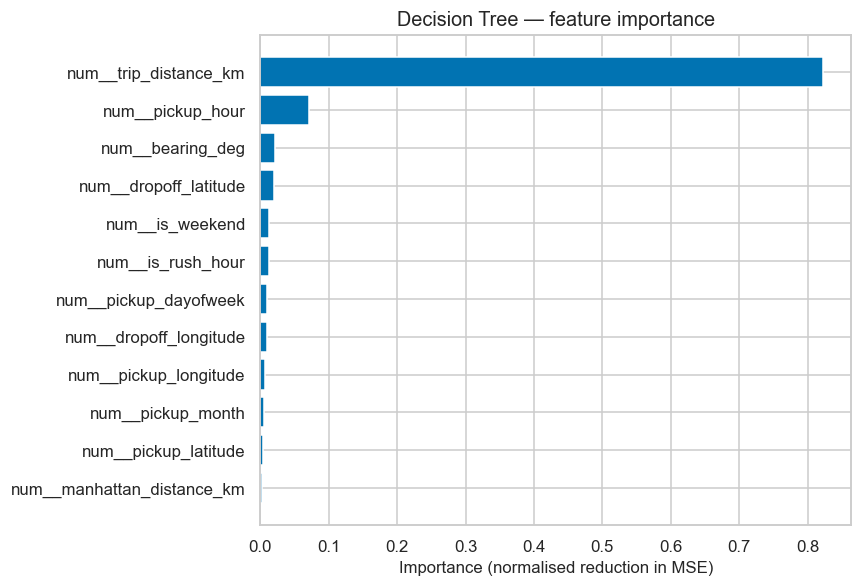

In [34]:
progress("Cluster G", "Decision Tree")
tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
)
tree, _, _ = evaluate("Decision Tree Regressor", tree, X_train_p, y_train)

tree_imp = (
    pd.Series(tree.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .to_frame("importance")
)
display(tree_imp.head(12))

fig, ax = plt.subplots(figsize=(8, 5.5))
top = tree_imp.head(12).iloc[::-1]
ax.barh(top.index, top["importance"], color=sns.color_palette("colorblind")[0])
ax.set_title("Decision Tree — feature importance")
ax.set_xlabel("Importance (normalised reduction in MSE)")
finalise(fig)


### G7. Random Forest

Many trees, each on a random slice of rows and columns, then average. More stable than one tree. `n_jobs=-1` uses all CPU cores. Cluster H will search `n_estimators` / `max_depth`.


In [35]:
progress("Cluster G", "Random Forest — slow; watch this cell")
forest = RandomForestRegressor(
    n_estimators=80,
    max_depth=18,
    min_samples_leaf=20,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)
forest, _, _ = evaluate("Random Forest Regressor", forest, X_train_p, y_train)

forest_imp = (
    pd.Series(forest.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .to_frame("importance")
)
display(forest_imp.head(10))


[21:22:38] Cluster G  |  Random Forest — slow; watch this cell


[21:22:38] Cluster G  |  Random Forest — slow; watch this cell


[21:22:38] fitting  |  Random Forest Regressor  on 279,264 rows


[21:22:38] fitting  |  Random Forest Regressor  on 279,264 rows
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  3.0min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s


[21:25:41] done  |  Random Forest Regressor  R2=0.7912  RMSE=295.0s  MAE=189.7s  (182.1s)


[Parallel(n_jobs=12)]: Done  80 out of  80 | elapsed:    0.6s finished
[21:25:41] done  |  Random Forest Regressor  R2=0.7912  RMSE=295.0s  MAE=189.7s  (182.1s)


,importance
num__trip_distance_km,0.7780
num__pickup_hour,0.0720
num__bearing_deg,0.0284
num__dropoff_latitude,0.0263
num__dropoff_longitude,0.0165
num__pickup_dayofweek,0.0161
num__pickup_longitude,0.0141
num__is_rush_hour,0.0123
num__pickup_latitude,0.0110
num__is_weekend,0.0088


### G8. Gradient Boosting

Trees added one after another, each fixing the previous one’s mistakes. sklearn’s classic `GradientBoostingRegressor` is too slow here, so we use **`HistGradientBoostingRegressor`** — still sklearn, same idea, built for large tables. `learning_rate=0.08`.


In [36]:
progress("Cluster G", "Gradient Boosting — prints each iteration")
gbm = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_depth=6,
    max_iter=200,
    l2_regularization=0.1,
    verbose=1,
    random_state=RANDOM_STATE,
)
gbm, _, _ = evaluate("Gradient Boosting Regressor", gbm, X_train_p, y_train)


[21:25:41] Cluster G  |  Gradient Boosting — prints each iteration


[21:25:41] Cluster G  |  Gradient Boosting — prints each iteration


[21:25:41] fitting  |  Gradient Boosting Regressor  on 279,264 rows


[21:25:41] fitting  |  Gradient Boosting Regressor  on 279,264 rows


Binning 0.034 GB of training data: 0.542 s
Binning 0.004 GB of validation data: 0.017 s
Fitting gradient boosted rounds:
Fit 200 trees in 15.862 s, (6200 total leaves)
Time spent computing histograms: 5.194s
Time spent finding best splits:  1.123s
Time spent applying splits:      2.844s
Time spent predicting:           0.315s
[21:25:58] done  |  Gradient Boosting Regressor  R2=0.7971  RMSE=290.8s  MAE=188.3s  (15.9s)


[21:25:58] done  |  Gradient Boosting Regressor  R2=0.7971  RMSE=290.8s  MAE=188.3s  (15.9s)


### G9. Support Vector Regressor (SVR)

Looks for a “tube” around the points in a high-dimensional space (RBF kernel). Training time grows roughly with *n²*, so we train on **12,000 training rows only**. Features are already scaled. The **target** is scaled too (`TransformedTargetRegressor`) because `C` and `epsilon` assume numbers near 0–1, not 800 seconds. We still **score the same test rows** as everyone else.


In [37]:
progress("Cluster G", "SVR on 12k rows — slow; watch this cell")
X_svr, y_svr = subset_train(SVR_TRAIN_SIZE)
print(f"SVR training subset: {len(X_svr):,} rows  |  test rows remain {len(X_test_p):,}")

svr = TransformedTargetRegressor(
    regressor=SVR(kernel="rbf", C=1.0, epsilon=0.1, verbose=True),
    transformer=StandardScaler(),
)
svr, _, _ = evaluate("Support Vector Regressor", svr, X_svr, y_svr)


[21:25:58] Cluster G  |  SVR on 12k rows — slow; watch this cell


[21:25:58] Cluster G  |  SVR on 12k rows — slow; watch this cell


SVR training subset: 12,000 rows  |  test rows remain 50,000
[21:25:58] fitting  |  Support Vector Regressor  on 12,000 rows


[21:25:58] fitting  |  Support Vector Regressor  on 12,000 rows


[LibSVM][21:28:24] done  |  Support Vector Regressor  R2=0.7281  RMSE=336.6s  MAE=213.1s  (18.1s)


[21:28:24] done  |  Support Vector Regressor  R2=0.7281  RMSE=336.6s  MAE=213.1s  (18.1s)


### G10. K-Nearest Neighbors

Predicts the average duration of the *k* closest training trips. `k=15`. Needs scaled features (otherwise longitude would dominate). We train on **40,000 rows** and still score the shared test set. Small *k* = jumpy; large *k* = too smooth.


In [38]:
progress("Cluster G", "KNN")
X_knn, y_knn = subset_train(KNN_TRAIN_SIZE)
print(f"KNN training subset: {len(X_knn):,} rows")

knn = KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=-1)
knn, _, _ = evaluate("K-Nearest Neighbors Regressor", knn, X_knn, y_knn)


[21:28:24] Cluster G  |  KNN


[21:28:24] Cluster G  |  KNN


KNN training subset: 40,000 rows
[21:28:24] fitting  |  K-Nearest Neighbors Regressor  on 40,000 rows


[21:28:24] fitting  |  K-Nearest Neighbors Regressor  on 40,000 rows


[21:28:35] done  |  K-Nearest Neighbors Regressor  R2=0.6993  RMSE=354.0s  MAE=243.5s  (0.0s)


[21:28:35] done  |  K-Nearest Neighbors Regressor  R2=0.6993  RMSE=354.0s  MAE=243.5s  (0.0s)


---
#  Compare, tune, and check

**Input:** `leaderboard` from Cluster G.  
**Output:** ranked table, tuned Ridge + Random Forest, residual plots, 5-fold CV on the top two official models.


### H1. Comparison table

One table, same test trips, ranked by R² (rubric C2). The mean baseline is included. **Train rows** shows that SVR/KNN did not see the full split.


[21:28:35] Cluster H  |  comparison table


[21:28:35] Cluster H  |  comparison table


,Rank,Model,Train rows,R2,RMSE,MAE,Fit seconds
0,1,Gradient Boosting Regressor,"279,264",0.7971,290.8,188.3,15.9
1,2,Random Forest Regressor,"279,264",0.7912,295.0,189.7,182.1
2,3,Decision Tree Regressor,"279,264",0.7506,322.4,211.5,9.6
3,4,Support Vector Regressor,"12,000",0.7281,336.6,213.1,18.1
4,5,Polynomial Regression,"279,264",0.7026,352.1,238.6,44.0
5,6,K-Nearest Neighbors Regressor,"40,000",0.6993,354.0,243.5,0.0
6,7,Ridge Regression,"279,264",0.6241,395.8,273.0,0.1
7,8,Linear Regression,"279,264",0.6241,395.8,273.0,0.2
8,9,Lasso Regression,"279,264",0.6240,395.8,273.2,14.8
9,10,ElasticNet Regression,"279,264",0.6092,403.5,281.6,1.3


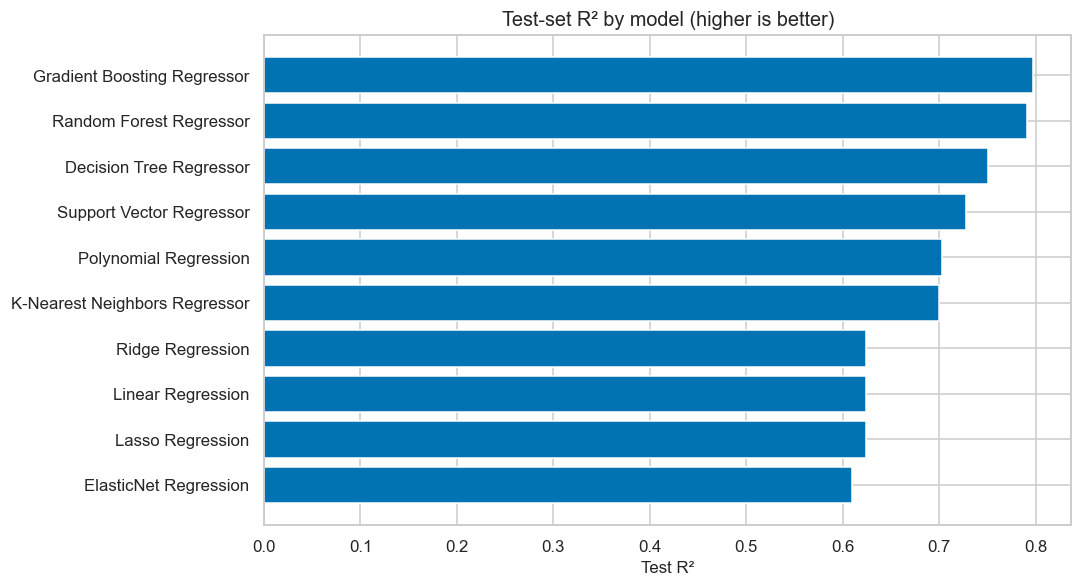

In [39]:
progress("Cluster H", "comparison table")
results = (
    pd.DataFrame(leaderboard)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
results.insert(0, "Rank", results.index + 1)
display(results.style.format(
    {
        "R2": "{:.4f}",
        "RMSE": "{:,.1f}",
        "MAE": "{:,.1f}",
        "Fit seconds": "{:,.1f}",
        "Train rows": "{:,}",
    }
))

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_res = results[results["Model"] != "Mean baseline"].iloc[::-1]
ax.barh(plot_res["Model"], plot_res["R2"], color=sns.color_palette("colorblind")[0])
ax.set_xlabel("Test R²")
ax.set_title("Test-set R² by model (higher is better)")
finalise(fig)


### H2. Hyperparameter tuning

Rubric C3: search **at least two** models and report the gain.

1. **Ridge** — `GridSearchCV` over `alpha` on the full training matrix (cheap).
2. **Random Forest** — `RandomizedSearchCV` on 40k rows, then refit the winner on the full training matrix.


In [40]:
progress("Cluster H", "GridSearchCV Ridge")
ridge_grid = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 250.0, 1000.0]},
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2,
)
ridge_grid.fit(X_train_p, y_train)
print("Ridge best params:", ridge_grid.best_params_)
print(f"Ridge best 5-fold CV R2: {ridge_grid.best_score_:.4f}")

ridge_untuned_r2 = next(r["R2"] for r in leaderboard if r["Model"] == "Ridge Regression")
ridge_tuned, y_ridge_tuned, row_ridge_tuned = evaluate(
    "Ridge Regression (tuned)",
    Ridge(**ridge_grid.best_params_, random_state=RANDOM_STATE),
    X_train_p,
    y_train,
)
print(f"Ridge test R2 before tuning: {ridge_untuned_r2:.4f}")
print(f"Ridge test R2 after tuning:  {row_ridge_tuned['R2']:.4f}")
print(f"Absolute improvement:        {row_ridge_tuned['R2'] - ridge_untuned_r2:+.4f}")


[21:28:37] Cluster H  |  GridSearchCV Ridge


[21:28:37] Cluster H  |  GridSearchCV Ridge


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Ridge best params: {'alpha': 0.001}
Ridge best 5-fold CV R2: 0.6208
[21:28:56] fitting  |  Ridge Regression (tuned)  on 279,264 rows


[21:28:56] fitting  |  Ridge Regression (tuned)  on 279,264 rows


[21:28:56] done  |  Ridge Regression (tuned)  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.2s)


[21:28:56] done  |  Ridge Regression (tuned)  R2=0.6241  RMSE=395.8s  MAE=273.0s  (0.2s)


Ridge test R2 before tuning: 0.6241
Ridge test R2 after tuning:  0.6241
Absolute improvement:        -0.0000


In [ ]:
progress("Cluster H", "RandomizedSearchCV Random Forest — slow")
X_tune, y_tune = subset_train(TUNE_SAMPLE_SIZE)

forest_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions={
        "n_estimators": [60, 80, 120],
        "max_depth": [12, 16, 20, None],
        "min_samples_leaf": [10, 20, 40],
        "max_features": ["sqrt", 0.5, 1.0],
    },
    n_iter=8,
    scoring="r2",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)
forest_search.fit(X_tune, y_tune)
print("Random Forest best params (from 40k search):", forest_search.best_params_)
print(f"Random Forest best 3-fold CV R2 on subset: {forest_search.best_score_:.4f}")

forest_untuned_r2 = next(r["R2"] for r in leaderboard if r["Model"] == "Random Forest Regressor")
forest_tuned, _, row_forest_tuned = evaluate(
    "Random Forest Regressor (tuned)",
    RandomForestRegressor(**forest_search.best_params_, n_jobs=-1, random_state=RANDOM_STATE),
    X_train_p,
    y_train,
)
print(f"Forest test R2 before tuning: {forest_untuned_r2:.4f}")
print(f"Forest test R2 after tuning:  {row_forest_tuned['R2']:.4f}")
print(f"Absolute improvement:         {row_forest_tuned['R2'] - forest_untuned_r2:+.4f}")


[21:28:56] Cluster H  |  RandomizedSearchCV Random Forest — slow


[21:28:56] Cluster H  |  RandomizedSearchCV Random Forest — slow


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest best params (from 40k search): {'n_estimators': 60, 'min_samples_leaf': 10, 'max_features': 1.0, 'max_depth': 16}
Random Forest best 3-fold CV R2 on subset: 0.7609
[21:31:22] fitting  |  Random Forest Regressor (tuned)  on 279,264 rows


[21:31:22] fitting  |  Random Forest Regressor (tuned)  on 279,264 rows


In [ ]:
results_tuned = (
    pd.DataFrame(leaderboard)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
results_tuned.insert(0, "Rank", results_tuned.index + 1)
display(results_tuned.style.format(
    {
        "R2": "{:.4f}",
        "RMSE": "{:,.1f}",
        "MAE": "{:,.1f}",
        "Fit seconds": "{:,.1f}",
        "Train rows": "{:,}",
    }
))


### H3. Diagnostics for the best model

Rubric C4: predicted vs actual, residual plot, and a tree-based feature-importance chart.


In [ ]:
progress("Cluster H", "best-model residual plots")
official = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "ElasticNet Regression",
    "Polynomial Regression",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "Support Vector Regressor",
    "K-Nearest Neighbors Regressor",
]
# Prefer a tuned sibling if it beat its parent
candidates = pd.DataFrame(leaderboard)
candidates = candidates[candidates["Model"].isin(official + [
    "Ridge Regression (tuned)",
    "Random Forest Regressor (tuned)",
])]
best_name = candidates.sort_values("R2", ascending=False).iloc[0]["Model"]
y_best = predictions[best_name]
residuals = y_test.to_numpy() - y_best

print(f"Best model by test R2: {best_name}")
print(candidates.sort_values("R2", ascending=False).head(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(y_best, y_test, s=8, alpha=0.2, linewidths=0)
lims = [min(y_best.min(), y_test.min()), max(y_best.max(), y_test.max())]
axes[0].plot(lims, lims, color="black", linewidth=1, label="Perfect prediction")
axes[0].set_title(f"Predicted vs actual — {best_name}")
axes[0].set_xlabel("Predicted duration (s)")
axes[0].set_ylabel("Actual duration (s)")
axes[0].legend()

axes[1].scatter(y_best, residuals, s=8, alpha=0.2, linewidths=0)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"Residuals vs predicted — {best_name}")
axes[1].set_xlabel("Predicted duration (s)")
axes[1].set_ylabel("Residual (actual − predicted, s)")

finalise(fig)
print(f"Residual mean: {residuals.mean():.2f}s   Residual std: {residuals.std():.2f}s")


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
importance_model = forest_tuned if "forest_tuned" in dir() else forest
imp_source = "Random Forest (tuned)" if importance_model is not forest else "Random Forest"
series = (
    pd.Series(importance_model.feature_importances_, index=feature_names)
    .sort_values(ascending=True)
    .tail(12)
)
ax.barh(series.index, series.values, color=sns.color_palette("colorblind")[2])
ax.set_title(f"{imp_source} — feature importance")
ax.set_xlabel("Importance")
finalise(fig)


### H4. 5-fold cross-validation

Required for the **two best official models**. CV uses **training rows only**. The test set stays untouched.


In [ ]:
progress("Cluster H", "5-fold CV of top two — slow")
ranked_official = (
    pd.DataFrame(leaderboard)
    .query("Model in @official")
    .sort_values("R2", ascending=False)
)
top_two_names = ranked_official["Model"].head(2).tolist()
print("Top two official models by test R2:", top_two_names)

rebuilders = {
    "Linear Regression": lambda: LinearRegression(),
    "Ridge Regression": lambda: Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": lambda: Lasso(alpha=0.5, max_iter=20000, random_state=RANDOM_STATE),
    "ElasticNet Regression": lambda: ElasticNet(alpha=0.2, l1_ratio=0.5, max_iter=20000, random_state=RANDOM_STATE),
    "Polynomial Regression": lambda: Pipeline(
        [
            ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
            ("lin", LinearRegression()),
        ]
    ),
    "Decision Tree Regressor": lambda: DecisionTreeRegressor(
        max_depth=12, min_samples_leaf=50, random_state=RANDOM_STATE
    ),
    "Random Forest Regressor": lambda: RandomForestRegressor(
        n_estimators=80, max_depth=18, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Gradient Boosting Regressor": lambda: HistGradientBoostingRegressor(
        learning_rate=0.08, max_depth=6, max_iter=200, l2_regularization=0.1, random_state=RANDOM_STATE
    ),
    "Support Vector Regressor": lambda: TransformedTargetRegressor(
        regressor=SVR(kernel="rbf", C=1.0, epsilon=0.1),
        transformer=StandardScaler(),
    ),
    "K-Nearest Neighbors Regressor": lambda: KNeighborsRegressor(
        n_neighbors=15, weights="distance", n_jobs=-1
    ),
}

cv_rows = []
for name in top_two_names:
    model = rebuilders[name]()
    if name == "Support Vector Regressor":
        X_cv, y_cv = X_svr, y_svr
    elif name == "K-Nearest Neighbors Regressor":
        X_cv, y_cv = X_knn, y_knn
    else:
        X_cv, y_cv = X_train_p, y_train
    progress("CV", name)
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring="r2", n_jobs=-1)
    cv_rows.append(
        {
            "Model": name,
            "CV folds": 5,
            "CV R2 mean": scores.mean(),
            "CV R2 std": scores.std(),
            "Fold scores": np.round(scores, 4),
        }
    )
    print(f"{name}: fold R2 = {np.round(scores, 4)}  mean={scores.mean():.4f}  std={scores.std():.4f}")

display(pd.DataFrame(cv_rows))


---
#  Manual tester

**Input:** the fitted models and the **same** `preprocess` object from Cluster F.  
**Output:** predicted duration (seconds and minutes) for a trip **you type in**.

Change the numbers in the next code cell, then re-run **that cell only**. The helper builds the same engineered columns as Cluster E, scales with the **already fitted** train scaler (no refitting), and scores the current best model plus the other fitted models.


In [ ]:
progress("Cluster I", "manual tester")
# =============================================================================
# EDIT THIS DICTIONARY, then re-run this cell.
# Coordinates are WGS84. pickup_datetime is local NYC time.
# vendor_id is 1 or 2. store_and_fwd_flag is "N" or "Y".
# =============================================================================
manual_trip = {
    "vendor_id": 2,
    "pickup_datetime": "2016-03-14 17:24:55",  # weekday evening — rush hour
    "passenger_count": 1,
    "pickup_longitude": -73.9822,
    "pickup_latitude": 40.7679,
    "dropoff_longitude": -73.9646,
    "dropoff_latitude": 40.7656,
    "store_and_fwd_flag": "N",
}

# Optional second trip for a quick sanity check (set to None to skip)
manual_trip_b = {
    "vendor_id": 1,
    "pickup_datetime": "2016-06-12 00:43:35",  # late night
    "passenger_count": 2,
    "pickup_longitude": -73.9804,
    "pickup_latitude": 40.7386,
    "dropoff_longitude": -73.9995,
    "dropoff_latitude": 40.7312,
    "store_and_fwd_flag": "N",
}


def predict_manual_trips(*trips):
    rows = [t for t in trips if t is not None]
    raw = pd.DataFrame(rows)
    needed = [
        "vendor_id",
        "pickup_datetime",
        "passenger_count",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "store_and_fwd_flag",
    ]
    missing = [c for c in needed if c not in raw.columns]
    if missing:
        raise ValueError(f"manual trip is missing columns: {missing}")

    fe = engineer_features(raw)
    X_manual = fe.reindex(columns=X_train.columns)
    if X_manual.isna().any().any():
        raise ValueError("manual features contain NaN — check column names and types.")
    X_manual_p = preprocess.transform(X_manual)

    # Prefer the overall best fitted model (tuned variants included)
    rank = pd.DataFrame(leaderboard).sort_values("R2", ascending=False)
    best = rank.iloc[0]["Model"]
    if best not in fitted_models:
        best = rank.loc[rank["Model"].isin(fitted_models), "Model"].iloc[0]

    out = X_manual.copy()
    out.insert(0, "trip", range(1, len(out) + 1))
    out["predicted_seconds"] = np.clip(fitted_models[best].predict(X_manual_p), 1, None)
    out["predicted_minutes"] = out["predicted_seconds"] / 60.0
    out["model_used"] = best

    print(f"Best model used: {best}")
    print(f"Engineered distance (km): {fe['trip_distance_km'].round(3).tolist()}")
    print(f"Rush hour flag:           {fe['is_rush_hour'].tolist()}")
    display(
        out[
            [
                "trip",
                "model_used",
                "predicted_seconds",
                "predicted_minutes",
                "passenger_count",
                "trip_distance_km",
                "pickup_hour",
                "is_rush_hour",
            ]
        ]
    )

    # Also score every fitted official model on trip 1 (helps the viva)
    trip1 = X_manual_p[0:1]
    compare = []
    for name, model in fitted_models.items():
        try:
            pred = float(np.clip(model.predict(trip1), 1, None)[0])
        except Exception:
            continue
        compare.append({"Model": name, "Predicted seconds": pred, "Predicted minutes": pred / 60.0})
    compare_df = pd.DataFrame(compare).sort_values("Predicted seconds")
    print("\\nTrip 1 — every fitted model:")
    display(compare_df)

    return out, compare_df


manual_predictions, manual_model_compare = predict_manual_trips(manual_trip, manual_trip_b)
